# Full Pipeline Accuracy Review

This notebook ingests all accuracy artifacts produced by `scripts/run_full_pipeline_llama_unlearn.sh` and
structures them into human-readable tables and figures.

* **Section 1** loads every `accuracies_ckpts*.json` file, validates the expected pipeline outputs, and prepares a tidy DataFrame.
* **Section 2** produces comparison tables for LLaMA and Qwen across MMLU / GSM8K / Code benchmarks (with client breakdowns).
* **Section 3** visualises the same comparisons with grouped bar charts (global-only first, then client-inclusive).

## 1. Data ingestion and formatting

In [1]:
import json
import re
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.options.display.float_format = '{:,.4f}'.format

In [2]:
FS_ROOT = Path.cwd()
PIPELINE_SCRIPT = FS_ROOT / "scripts" / "run_full_pipeline_llama_unlearn.sh"
EVAL_DIR = FS_ROOT / "eval_result"
RESULTS_DIR = FS_ROOT / "results_full"
LOG_DIR = FS_ROOT / "logs"

print(f"Repo root        : {FS_ROOT}")
print(f"Pipeline script  : {PIPELINE_SCRIPT}")
print(f"Eval artifacts   : {EVAL_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Logs directory   : {LOG_DIR}")

for path, desc in [
    (PIPELINE_SCRIPT, "pipeline script"),
    (EVAL_DIR, "eval_result directory"),
    (RESULTS_DIR, "results_full directory"),
    (LOG_DIR, "logs directory"),
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {desc}: {path}")

Repo root        : /storage/ice1/7/0/sbhansali8/FederatedScope
Pipeline script  : /storage/ice1/7/0/sbhansali8/FederatedScope/scripts/run_full_pipeline_llama_unlearn.sh
Eval artifacts   : /storage/ice1/7/0/sbhansali8/FederatedScope/eval_result
Results directory: /storage/ice1/7/0/sbhansali8/FederatedScope/results_full
Logs directory   : /storage/ice1/7/0/sbhansali8/FederatedScope/logs


In [3]:
MODEL_DIR_TO_KEY = {
    'llama2': 'llama2_composite_meta3',
    'llama2_unlearn': 'llama2_composite_meta3_unlearn',
    'llama2_unlearn_shrink05': 'llama2_composite_meta3_unlearn_shrink05',
    'qwen_moe': 'qwen15moe_composite_meta3',
}

BENCHMARK_NORMALIZATION = {
    'all_in_one': 'mmlu',
    'code_local': 'code',
    'gsm8k_local': 'gsm8k',
    'instr_local': 'instructions',
    None: 'mmlu',
    '': 'mmlu'
}

BENCHMARK_LABELS = {
    'mmlu': 'MMLU',
    'gsm8k': 'GSM8K',
    'code': 'Code',
    'instructions': 'Instructions'
}

FAMILY_LABELS = {
    'llama2': 'LLaMA 2',
    'llama2_composite_meta3': 'LLaMA 2',
    'llama2_composite_meta3_unlearn': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_shrink05': 'LLaMA 2',
    'qwen_moe': 'Qwen 1.5 MoE',
    'qwen15moe': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3': 'Qwen 1.5 MoE'
}

CATEGORY_ORDER = [
    'STEM',
    'humanities',
    'social sciences',
    'other (business, health, misc.)'
]

FAMILY_BENCHMARKS = {
    'LLaMA 2': ['mmlu', 'gsm8k', 'code'],
    'Qwen 1.5 MoE': ['mmlu', 'gsm8k', 'code']
}

COLUMN_SPECS_GLOBAL = [
    ('Global — Baseline', {'scope': 'baseline'}),
    ('Global — Standard', {'scope': 'global', 'variant': 'Standard'}),
    ('Global — Unlearn', {'scope': 'global', 'variant': 'Unlearn'}),
    ('Global — Unlearn (shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (shrink=0.5)'})
]

CLIENT_IDS = ['client_1', 'client_2', 'client_3']
COLUMN_SPECS_CLIENTS = []
for client in CLIENT_IDS:
    human_name = client.replace('client_', 'Client ')
    COLUMN_SPECS_CLIENTS.append((f"{human_name} — Standard", {
        'scope': 'client', 'variant': 'Standard', 'client': client
    }))
    COLUMN_SPECS_CLIENTS.append((f"{human_name} — Unlearn (shrink=0.5)", {
        'scope': 'client', 'variant': 'Unlearn (shrink=0.5)', 'client': client
    }))

FAMILY_LABEL_DISPLAY_ORDER = ['LLaMA 2', 'Qwen 1.5 MoE']

In [4]:
def infer_family(model_key: str) -> str:
    for token, label in FAMILY_LABELS.items():
        if model_key.startswith(token):
            return label
    return model_key


def infer_variant(model_key: str, scope: str, benchmark: Optional[str], client: Optional[str]) -> str:
    if scope == 'baseline':
        if benchmark:
            return f"Baseline ({benchmark.replace('_', ' ').title()})"
        return 'Baseline'
    if scope == 'client':
        if client:
            human_client = client.replace('client_', 'Client ')
            return human_client.strip().title()
        return 'Client'
    if 'unlearn_shrink05' in model_key:
        return 'Unlearn (shrink=0.5)'
    if 'unlearn' in model_key:
        return 'Unlearn'
    return 'Standard'


def parse_accuracy_file(path: Path) -> dict:
    with path.open() as f:
        payload = json.load(f)

    raw_name = path.name.replace('accuracies_ckpts_', '').replace('.ckpt.json', '')
    scale = 'full' if raw_name.startswith('full_') else 'default'
    descriptor = raw_name[5:] if scale == 'full' else raw_name

    scope = 'global'
    model_key = descriptor
    benchmark = None
    client = None
    lookup_key = model_key

    if descriptor.startswith('baselines_'):
        scope = 'baseline'
        rest = descriptor[len('baselines_'):]
        parts = rest.split('_', 1)
        model_key = parts[0]
        benchmark = parts[1] if len(parts) > 1 else None
        lookup_key = model_key
    elif '_clients_' in descriptor:
        scope = 'client'
        model_key, client_part = descriptor.split('_clients_', 1)
        match = re.search(r'client_(\d+)', client_part)
        client = f"client_{match.group(1)}" if match else client_part
        lookup_key = model_key

    family = infer_family(model_key)
    variant = infer_variant(model_key, scope, benchmark, client)

    record = {
        'file': str(path.relative_to(FS_ROOT)),
        'raw_name': raw_name,
        'scale': scale,
        'scope': scope,
        'model_key': model_key,
        'lookup_key': lookup_key,
        'model_family': family,
        'variant': variant,
        'benchmark': benchmark,
        'client': client,
        'weighted_accuracy': payload.get('weighted_accuracy'),
        'categories': payload.get('categories', {}),
        'subcategories': payload.get('subcategories', {}),
    }
    record['match_key'] = (
        record['scope'],
        record['scale'],
        record['lookup_key'],
        record['benchmark'] or '',
        record['client'] or ''
    )
    return record

records = []
for accuracy_path in sorted(EVAL_DIR.glob('accuracies_ckpts*.json')):
    try:
        records.append(parse_accuracy_file(accuracy_path))
    except json.JSONDecodeError as exc:
        print(f"Skipping {accuracy_path}: {exc}")

if not records:
    raise RuntimeError('No accuracy files were found – rerun the evaluations.')

records_df = pd.DataFrame(records)
category_columns = sorted({k for rec in records for k in rec['categories'].keys()})
for col in category_columns:
    records_df[col] = records_df['categories'].apply(lambda d: d.get(col))

records_df['benchmark_norm'] = records_df.apply(
    lambda row: BENCHMARK_NORMALIZATION.get(row['benchmark'], 'mmlu'), axis=1
)
records_df['benchmark_label'] = records_df['benchmark_norm'].map(
    lambda key: BENCHMARK_LABELS.get(key, key)
)
records_df = records_df.sort_values(by=['scope', 'model_family', 'variant']).reset_index(drop=True)

print(f"Loaded {len(records_df)} accuracy artifacts.")
display(records_df.head())

Loaded 35 accuracy artifacts.


,file,raw_name,scale,scope,model_key,lookup_key,model_family,variant,benchmark,client,weighted_accuracy,categories,subcategories,match_key,STEM,humanities,"other (business, health, misc.)",social sciences,benchmark_norm,benchmark_label
0,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_all_in_one,default,baseline,llama2,llama2,LLaMA 2,Baseline (All In One),all_in_one,None,0.4138,"{'STEM': 0.35321404903909875, 'humanities': 0....",{},"(baseline, default, llama2, all_in_one, )",0.3532,0.3535,0.4827,0.4927,mmlu,MMLU
1,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All In One),all_in_one,None,0.4065,"{'STEM': 0.3565275016567263, 'humanities': 0.3...",{},"(baseline, full, llama2, all_in_one, )",0.3565,0.3373,0.4738,0.4904,mmlu,MMLU
2,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_code_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,None,0.3722,"{'STEM': 0.3442677269715043, 'humanities': 0.3...",{},"(baseline, default, llama2, code_local, )",0.3443,0.3269,0.4056,0.4335,code,Code
3,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_code_local,full,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,None,0.3456,"{'STEM': 0.2945659377070908, 'humanities': 0.3...",{},"(baseline, full, llama2, code_local, )",0.2946,0.3141,0.4038,0.3825,code,Code
4,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_gsm8k_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Gsm8K Local),gsm8k_local,None,0.3616,"{'STEM': 0.31245858184227965, 'humanities': 0....",{},"(baseline, default, llama2, gsm8k_local, )",0.3125,0.3282,0.4244,0.3945,gsm8k,GSM8K


In [5]:
expected_entries = []

for dir_name, model_key in MODEL_DIR_TO_KEY.items():
    candidate = RESULTS_DIR / 'global' / dir_name
    if candidate.exists():
        for benchmark in candidate.iterdir():
            if benchmark.is_dir():
                expected_entries.append({
                    'scope': 'global', 'scale': 'full', 'lookup_key': model_key,
                    'benchmark': benchmark.name, 'client': '', 'source_path': str(benchmark)
                })

clients_root = RESULTS_DIR / 'clients'
if clients_root.exists():
    for dir_name, model_key in MODEL_DIR_TO_KEY.items():
        model_dir = clients_root / dir_name
        if not model_dir.exists():
            continue
        for client_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
            expected_entries.append({
                'scope': 'client', 'scale': 'full', 'lookup_key': model_key,
                'benchmark': client_dir.name, 'client': client_dir.name, 'source_path': str(client_dir)
            })

baselines_root = RESULTS_DIR / 'baselines'
if baselines_root.exists():
    for model_dir in sorted(p for p in baselines_root.iterdir() if p.is_dir()):
        for bench_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
            expected_entries.append({
                'scope': 'baseline', 'scale': 'full', 'lookup_key': model_dir.name,
                'benchmark': bench_dir.name, 'client': '', 'source_path': str(bench_dir)
            })

expected_df = pd.DataFrame(expected_entries)
if expected_df.empty:
    print('results_full/ is empty – no expectations could be derived.')
else:
    expected_df['match_key'] = list(zip(
        expected_df['scope'], expected_df['scale'], expected_df['lookup_key'],
        expected_df['benchmark'], expected_df['client']
    ))
    have_keys = set(records_df['match_key'])
    expected_df['present'] = expected_df['match_key'].apply(lambda key: key in have_keys)
    missing_df = expected_df[~expected_df['present']].copy()
    if missing_df.empty:
        print('All expected accuracy files are present in eval_result/.')
    else:
        print('Accuracy artifacts missing from eval_result/:')
        display(missing_df[['scope', 'lookup_key', 'benchmark', 'client', 'source_path']])

Accuracy artifacts missing from eval_result/:


,scope,lookup_key,benchmark,client,source_path
0,global,llama2_composite_meta3,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
1,global,llama2_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
2,global,llama2_composite_meta3,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
3,global,llama2_composite_meta3_unlearn,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
4,global,llama2_composite_meta3_unlearn,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
5,global,llama2_composite_meta3_unlearn,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
6,global,llama2_composite_meta3_unlearn_shrink05,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
7,global,llama2_composite_meta3_unlearn_shrink05,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
8,global,llama2_composite_meta3_unlearn_shrink05,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
9,global,qwen15moe_composite_meta3,gsm8k,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...


## 2. Human-readable tables

In [6]:
def fetch_metric(family: str, benchmark: str, scope: str, variant: Optional[str] = None,
                 client: Optional[str] = None, scale: str = 'full') -> float:
    subset = records_df[
        (records_df['model_family'] == family) &
        (records_df['benchmark_norm'] == benchmark) &
        (records_df['scope'] == scope) &
        (records_df['scale'] == scale)
    ]
    if variant is not None:
        subset = subset[subset['variant'] == variant]
    if client is not None:
        subset = subset[subset['client'] == client]
    if subset.empty:
        return np.nan
    return subset.iloc[0]['weighted_accuracy']


def build_family_table(family: str) -> pd.DataFrame:
    rows = []
    for benchmark in FAMILY_BENCHMARKS.get(family, []):
        row = {'Benchmark': BENCHMARK_LABELS.get(benchmark, benchmark)}
        for label, spec in COLUMN_SPECS_GLOBAL + COLUMN_SPECS_CLIENTS:
            value = fetch_metric(
                family=family,
                benchmark=benchmark,
                scope=spec['scope'],
                variant=spec.get('variant'),
                client=spec.get('client')
            )
            row[label] = value
        rows.append(row)
    df = pd.DataFrame(rows)
    return df

llama_table = build_family_table('LLaMA 2')
print('LLaMA 2 accuracy summary (global + clients):')
display(llama_table)

missing_llama = []
for benchmark in FAMILY_BENCHMARKS['LLaMA 2']:
    for label, spec in COLUMN_SPECS_GLOBAL + COLUMN_SPECS_CLIENTS:
        val = fetch_metric('LLaMA 2', benchmark, spec['scope'], spec.get('variant'), spec.get('client'))
        if np.isnan(val):
            missing_llama.append({'Benchmark': BENCHMARK_LABELS.get(benchmark, benchmark), 'Column': label})
if missing_llama:
    print('Unavailable LLaMA values (will display as NaN above):')
    display(pd.DataFrame(missing_llama))

LLaMA 2 accuracy summary (global + clients):


,Benchmark,Global — Baseline,Global — Standard,Global — Unlearn,Global — Unlearn (shrink=0.5),Client 1 — Standard,Client 1 — Unlearn (shrink=0.5),Client 2 — Standard,Client 2 — Unlearn (shrink=0.5),Client 3 — Standard,Client 3 — Unlearn (shrink=0.5)
0,MMLU,0.4065,0.2711,0.4162,0.4173,NaN,NaN,NaN,NaN,NaN,NaN
1,GSM8K,0.3845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Code,0.3456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unavailable LLaMA values (will display as NaN above):


,Benchmark,Column
0,MMLU,Client 1 — Standard
1,MMLU,Client 1 — Unlearn (shrink=0.5)
2,MMLU,Client 2 — Standard
3,MMLU,Client 2 — Unlearn (shrink=0.5)
4,MMLU,Client 3 — Standard
5,MMLU,Client 3 — Unlearn (shrink=0.5)
6,GSM8K,Global — Standard
7,GSM8K,Global — Unlearn
8,GSM8K,Global — Unlearn (shrink=0.5)
9,GSM8K,Client 1 — Standard


In [ ]:
qwen_table = build_family_table('Qwen 1.5 MoE')
print('Qwen 1.5 MoE accuracy summary (global + clients):')
display(qwen_table)

missing_qwen = []
for benchmark in FAMILY_BENCHMARKS['Qwen 1.5 MoE']:
    for label, spec in COLUMN_SPECS_GLOBAL + COLUMN_SPECS_CLIENTS:
        val = fetch_metric('Qwen 1.5 MoE', benchmark, spec['scope'], spec.get('variant'), spec.get('client'))
        if np.isnan(val):
            missing_qwen.append({'Benchmark': BENCHMARK_LABELS.get(benchmark, benchmark), 'Column': label})
if missing_qwen:
    print('Unavailable Qwen values (will display as NaN above):')
    display(pd.DataFrame(missing_qwen))

## 3. Graphs

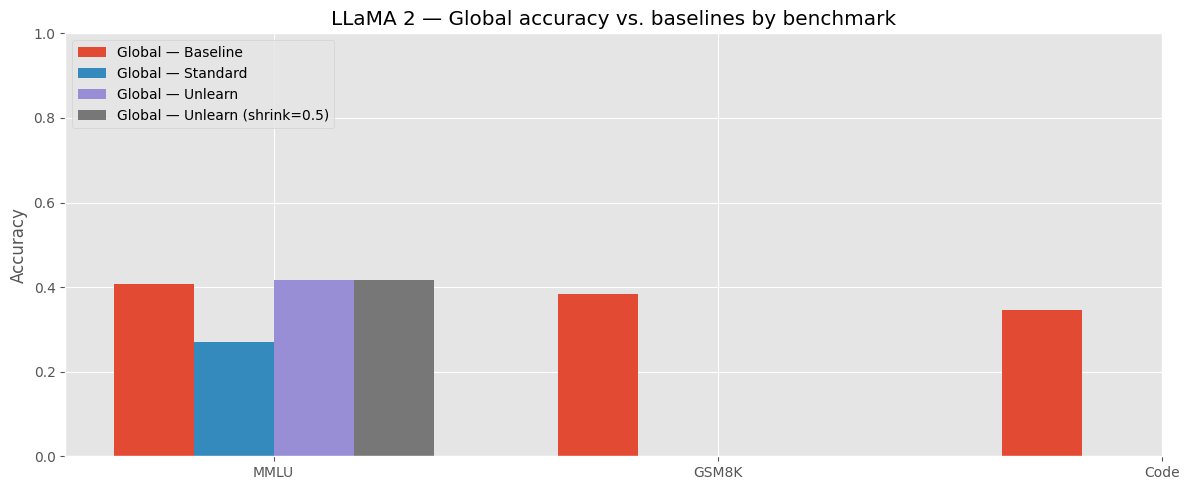

In [7]:
def plot_global_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    variants = [label for label, _ in COLUMN_SPECS_GLOBAL]
    data = []
    for benchmark in benches:
        for label, spec in COLUMN_SPECS_GLOBAL:
            val = fetch_metric(family, benchmark, spec['scope'], spec.get('variant'))
            data.append({'Benchmark': BENCHMARK_LABELS.get(benchmark, benchmark),
                         'Variant': label, 'Accuracy': val})
    plot_df = pd.DataFrame(data)
    if plot_df['Accuracy'].notna().sum() == 0:
        print(f'No global accuracies available for {family}.')
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    x_positions = np.arange(len(benches))
    width = 0.18
    for idx, variant in enumerate(variants):
        subset = plot_df[plot_df['Variant'] == variant]
        accuracies = [subset[subset['Benchmark'] == BENCHMARK_LABELS.get(bench, bench)]['Accuracy'].values[0]
                      if not subset[subset['Benchmark'] == BENCHMARK_LABELS.get(bench, bench)].empty else np.nan
                      for bench in benches]
        offsets = x_positions + (idx - (len(variants) - 1) / 2) * width
        ax.bar(offsets, accuracies, width=width, label=variant)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([BENCHMARK_LABELS.get(b, b) for b in benches])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{family} — Global accuracy vs. baselines by benchmark')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_global_benchmarks('LLaMA 2')

In [8]:
def plot_client_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    variants = [label for label, _ in COLUMN_SPECS_CLIENTS]
    data = []
    for benchmark in benches:
        for label, spec in COLUMN_SPECS_CLIENTS:
            val = fetch_metric(family, benchmark, spec['scope'], spec.get('variant'), spec.get('client'))
            data.append({'Benchmark': BENCHMARK_LABELS.get(benchmark, benchmark),
                         'Variant': label, 'Accuracy': val})
    plot_df = pd.DataFrame(data)
    if plot_df['Accuracy'].notna().sum() == 0:
        print(f'No client accuracies available for {family}.')
        return

    fig, ax = plt.subplots(figsize=(14, 5))
    x_positions = np.arange(len(benches))
    width = 0.12
    for idx, variant in enumerate(variants):
        subset = plot_df[plot_df['Variant'] == variant]
        accuracies = [subset[subset['Benchmark'] == BENCHMARK_LABELS.get(bench, bench)]['Accuracy'].values[0]
                      if not subset[subset['Benchmark'] == BENCHMARK_LABELS.get(bench, bench)].empty else np.nan
                      for bench in benches]
        offsets = x_positions + (idx - (len(variants) - 1) / 2) * width
        ax.bar(offsets, accuracies, width=width, label=variant)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([BENCHMARK_LABELS.get(b, b) for b in benches])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{family} — Client accuracy vs. baselines by benchmark')
    ax.legend(ncol=2, bbox_to_anchor=(1.05, 1.0))
    plt.tight_layout()
    plt.show()

plot_client_benchmarks('LLaMA 2')

No client accuracies available for LLaMA 2.


In [ ]:
plot_global_benchmarks('Qwen 1.5 MoE')

In [ ]:
plot_client_benchmarks('Qwen 1.5 MoE')